In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import pygenelab as pgl
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import scanpy as sc

# Append the src directory to the path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

working_dir = "/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing"

In [39]:
human_adata = '/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing/objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'
adata = sc.read_h5ad(human_adata)

In [40]:
adata.obs['age'].value_counts()

age
80    2000
34    1989
Name: count, dtype: int64

In [41]:
adata.obs['Annotation'].value_counts()

Annotation
Type II        3391
ENOX1+ (II)     350
ID1+ (II)       241
DCLK1+ (II)       4
SAA2+ (II)        2
TNNT2+ (II)       1
Name: count, dtype: int64

In [42]:
adata

AnnData object with n_obs × n_vars = 3989 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'

#### Sparsity based gene filtering

In [43]:
import numpy as np
from scipy.sparse import issparse

def calculate_zero_proportion(adata, axis='genes'):
    """
    Calculate the proportion of zeros for either genes (features) or cells in an AnnData object.
    
    Parameters:
    -----------
    adata : AnnData
        The AnnData object containing gene expression data
    axis : str, default 'genes'
        Which axis to calculate zeros for:
        - 'genes' or 'features' or 'columns': calculate zeros per gene (column-wise)
        - 'cells' or 'rows': calculate zeros per cell (row-wise)
        
    Returns:
    --------
    proportion_zeros : numpy.ndarray
        Array containing the proportion of zeros for each gene or cell
    """
    if axis.lower() in ['genes', 'features', 'columns']:
        # Calculate zeros per gene (column-wise)
        if issparse(adata.X):
            # For sparse matrix: count non-zeros, then calculate zeros
            n_cells = adata.n_obs
            non_zero_per_gene = np.array((adata.X != 0).sum(axis=0)).flatten()
            zero_per_gene = n_cells - non_zero_per_gene
            proportion_zeros = zero_per_gene / n_cells
        else:
            # For dense matrix
            proportion_zeros = (adata.X == 0).sum(axis=0) / adata.n_obs
            
    elif axis.lower() in ['cells', 'rows']:
        # Calculate zeros per cell (row-wise)
        if issparse(adata.X):
            # For sparse matrix: count non-zeros, then calculate zeros
            n_genes = adata.n_vars
            non_zero_per_cell = np.array((adata.X != 0).sum(axis=1)).flatten()
            zero_per_cell = n_genes - non_zero_per_cell
            proportion_zeros = zero_per_cell / n_genes
        else:
            # For dense matrix
            proportion_zeros = (adata.X == 0).sum(axis=1) / adata.n_vars
    else:
        raise ValueError("axis must be 'genes', 'features', 'columns', 'cells', or 'rows'")
    
    return proportion_zeros

def plot_sparsity_analysis(proportion_zeros, str='features', figsize=(14, 5), bins=50, 
                                color='steelblue', alpha=0.7, show_stats=True):
    """
    Plot cell/feature sparsity analysis with histogram and cumulative distribution.
    
    Parameters:
    -----------
    proportion_zeros : numpy.ndarray
        Array containing the proportion of zeros for each feature/cell
    figsize : tuple, default (14, 5)
        Figure size for the plots
    bins : int, default 50
        Number of bins for the histogram
    color : str, default 'steelblue'
        Color for the histogram bars
    alpha : float, default 0.7
        Transparency for the histogram bars
    show_stats : bool, default True
        Whether to print summary statistics
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    axes : numpy.ndarray
        Array of axes objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: Histogram of cell/feature sparsity
    axes[0].hist(proportion_zeros, bins=bins, edgecolor='black', alpha=alpha, color=color)
    axes[0].set_xlabel('Proportion of zeros')
    axes[0].set_ylabel('Number of ' + str)
    axes[0].set_title('Sparsity')
    axes[0].axvline(proportion_zeros.mean(), color='red', linestyle='--', 
                    label=f'Mean = {proportion_zeros.mean():.2f}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: Cumulative distribution
    sorted_props = np.sort(proportion_zeros)
    cumulative = np.arange(1, len(sorted_props) + 1) / len(sorted_props)
    axes[1].plot(sorted_props, cumulative, linewidth=2)
    axes[1].set_xlabel('Proportion of zeros')
    axes[1].set_ylabel('Cumulative fraction of ' + str)
    axes[1].set_title('Cumulative Distribution of Sparsity')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary statistics
    if show_stats:
        print(f"Total {str}: {len(proportion_zeros)}")
        print(f"Mean proportion of zeros: {proportion_zeros.mean():.3f}")
        print(f"Median proportion of zeros: {np.median(proportion_zeros):.3f}")
        print(f"\n{str} by sparsity:")
        print(f"  >95% zeros: {(proportion_zeros > 0.95).sum()} {str} ({(proportion_zeros > 0.95).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  >94% zeros: {(proportion_zeros > 0.94).sum()} {str} ({(proportion_zeros > 0.94).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  >90% zeros: {(proportion_zeros > 0.90).sum()} {str} ({(proportion_zeros > 0.90).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  All zeros:  {(proportion_zeros == 1.0).sum()} {str}")
    
    return fig, axes


In [44]:
proportion_zeros_feature = calculate_zero_proportion(adata, axis='features')

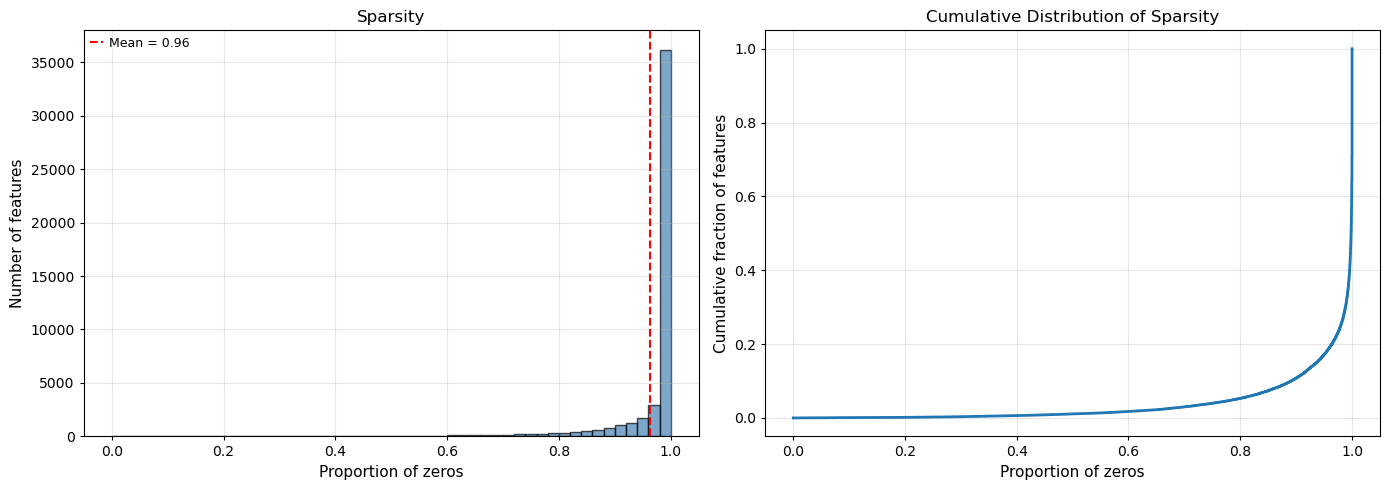

Total features: 48355
Mean proportion of zeros: 0.963
Median proportion of zeros: 0.998

features by sparsity:
  >95% zeros: 40066 features (82.9%)
  >94% zeros: 40858 features (84.5%)
  >90% zeros: 43140 features (89.2%)
  All zeros:  13973 features


In [45]:
# Plot the analysis
fig, axes = plot_sparsity_analysis(proportion_zeros_feature, str='features')

In [46]:
# Remove genes with all zeros
genes_to_keep = proportion_zeros_feature < 0.9

print(f"Before filtering: {adata.n_vars} genes")
adata_filtered = adata[:, genes_to_keep]
print(f"After filtering: {adata_filtered.n_vars} genes")
print(f"Removed: {(~genes_to_keep).sum()} genes")

Before filtering: 48355 genes
After filtering: 5215 genes
Removed: 43140 genes


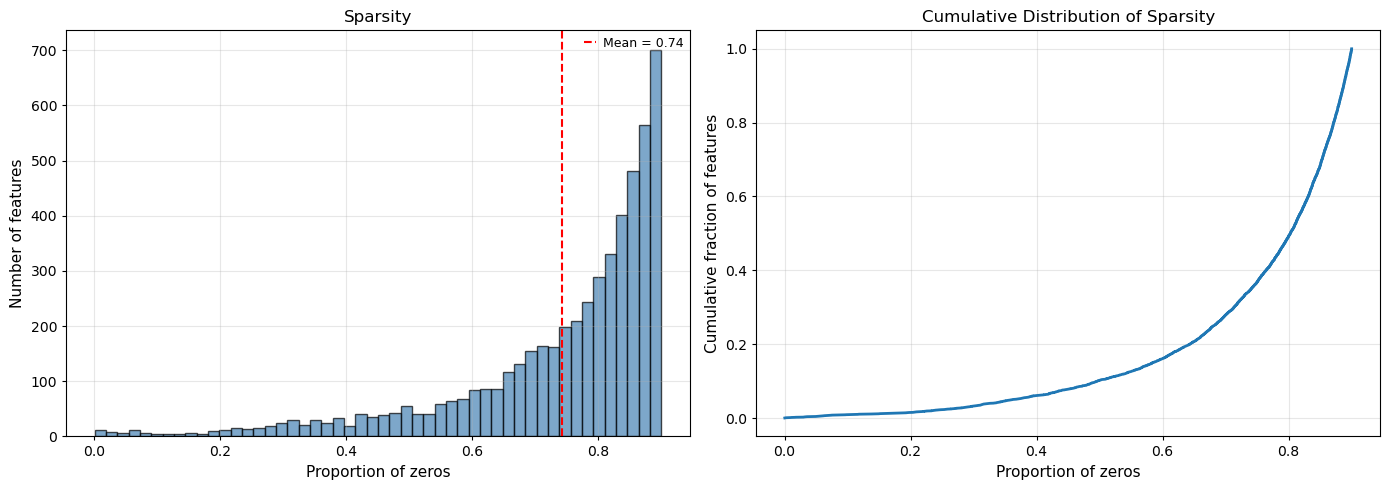

Total features: 5215
Mean proportion of zeros: 0.742
Median proportion of zeros: 0.803

features by sparsity:
  >95% zeros: 0 features (0.0%)
  >94% zeros: 0 features (0.0%)
  >90% zeros: 0 features (0.0%)
  All zeros:  0 features


In [47]:
proportion_zeros_feature = calculate_zero_proportion(adata_filtered, axis='features')
# Plot the analysis
fig, axes = plot_sparsity_analysis(proportion_zeros_feature, str='features')